# STATE for Virtual Cell Challenge

This notebook walks through how to train a STATE model for context generalization in the Arc [Virtual Cell Challenge](https://virtualcellchallenge.org/).

While STATE was not designed specifically for this setting (1. transcriptome-wide effect prediction and 2. predicting effects of perturbations unseen in any context in the test dataset), we present here an adapted version based on the model introduced in the paper. In particular, we simplify the basal encoder to a linear layer and shift the residual connection to the final expression prediction space. For more details on STATE, please refer to the [preprint](https://www.biorxiv.org/content/10.1101/2025.06.26.661135).

If you use STATE to participate in the Virtual Cell Competition, we ask that you mention it in your model description (and if you are a finalist you'll be required to share this information).

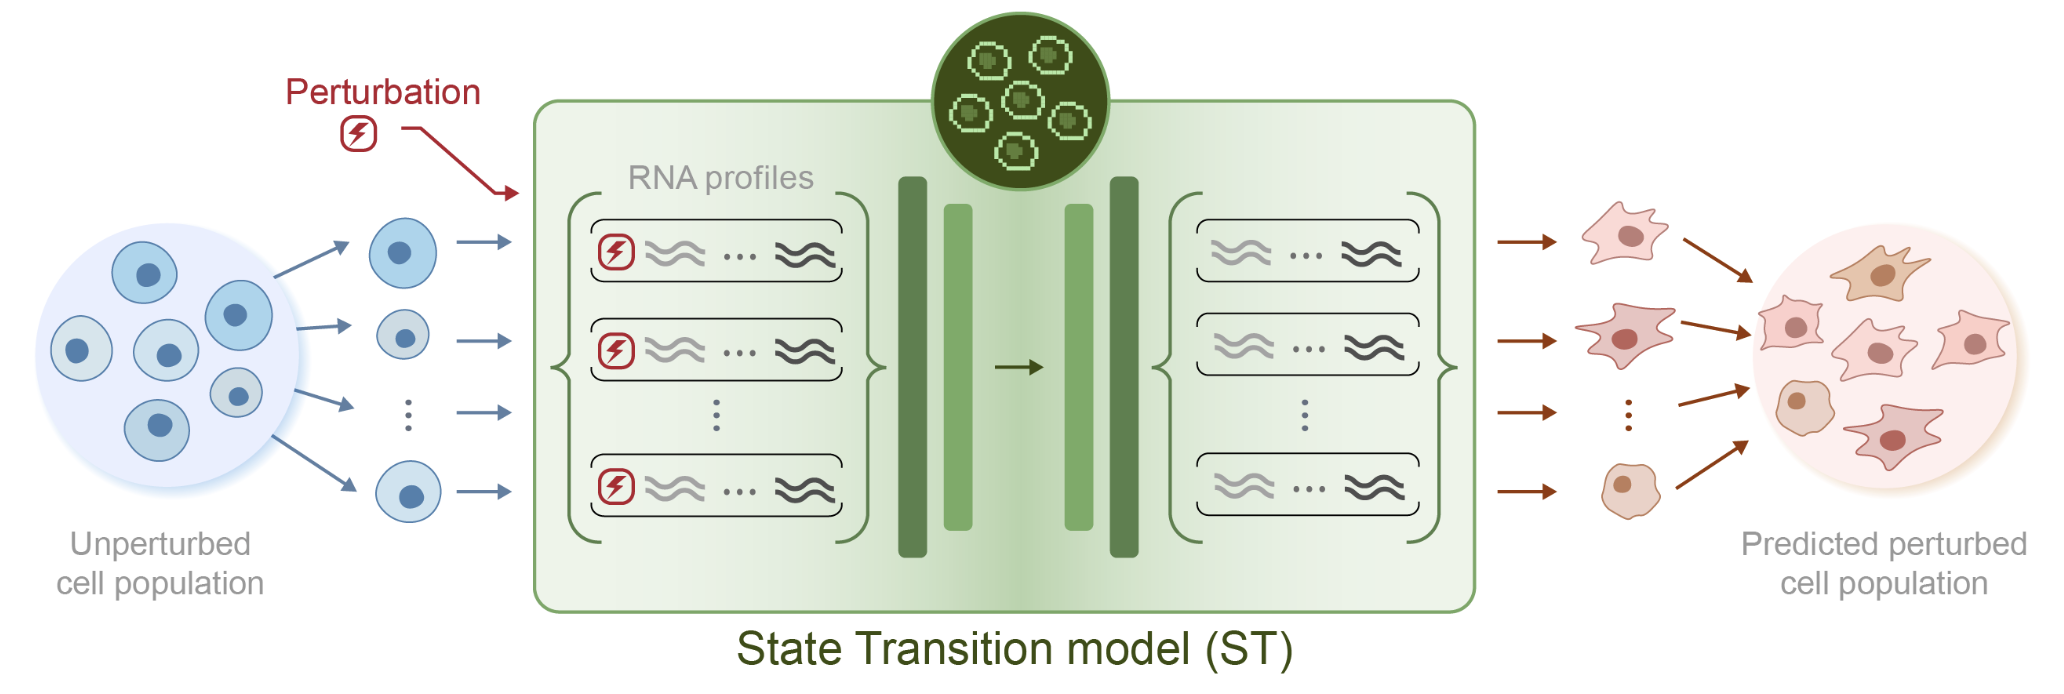

# Clone the repository.

In [ ]:
# Clone the repository
! git clone https://github.com/ArcInstitute/state.git
%cd state

# Colab-specific config for pytorch lightning
import os
os.environ['MPLBACKEND'] = 'Agg'

Cloning into 'state'...
remote: Enumerating objects: 8447, done.
remote: Counting objects: 100% (1748/1748), done.
remote: Compressing objects: 100% (384/384), done.
remote: Total 8447 (delta 1554), reused 1363 (delta 1363), pack-reused 6699 (from 2)
Receiving objects: 100% (8447/8447), 126.06 MiB | 17.04 MiB/s, done.
Resolving deltas: 100% (5275/5275), done.
/content/state


# Training Data Setup

The training and validation data provided for the Virtual Cell Challenge is from H1 cells. STATE is meant for context generalization, not perturbation generalization, so we need a separate dataset to jointly train on to learn perturbation embeddings. In our case, we jointly train on the [Replogle genome wide and essential screens](https://plus.figshare.com/articles/dataset/_Mapping_information-rich_genotype-phenotype_landscapes_with_genome-scale_Perturb-seq_Replogle_et_al_2022_processed_Perturb-seq_datasets/20029387). We have already filtered the data to only include the 200 perturbations that appear in the competition train / val set.

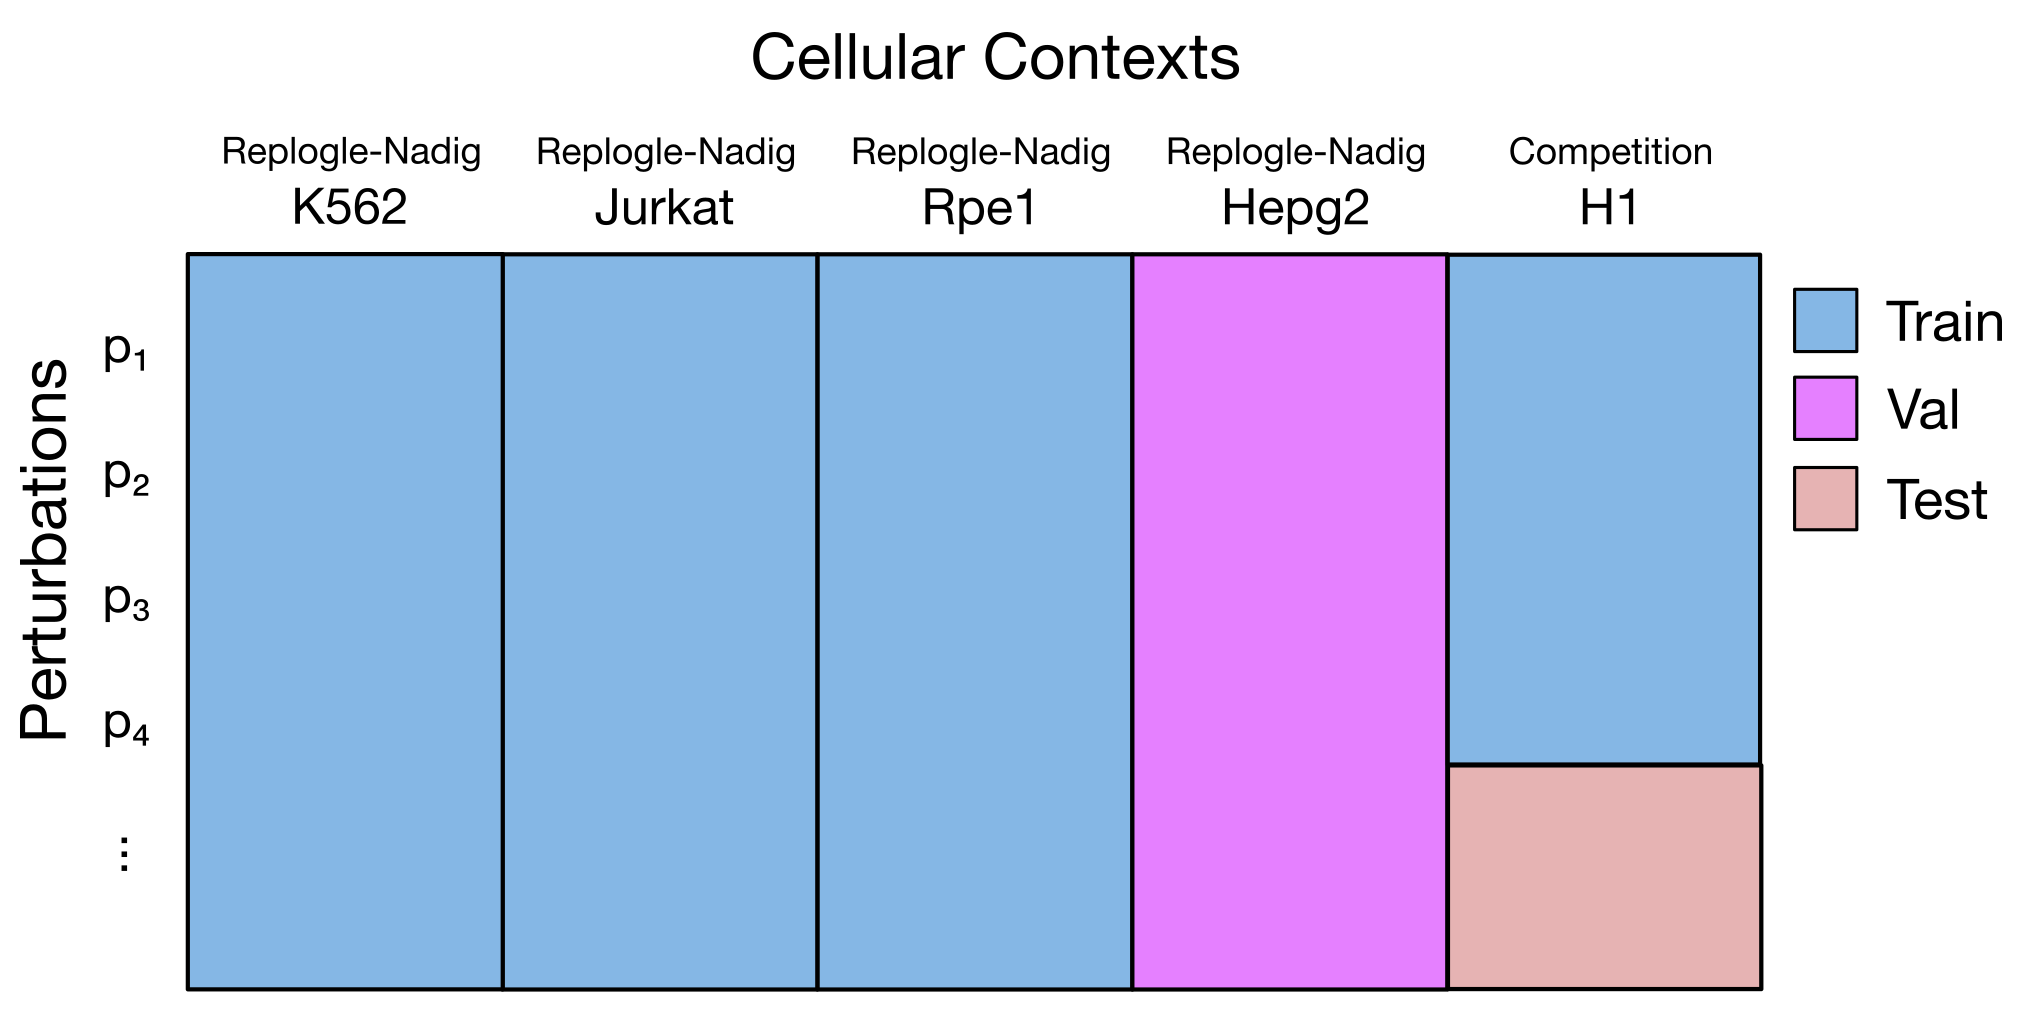

Users are encouraged to experiment with other datasets for model training!

# Download the Replogle-Nadig training dataset.

In [ ]:
%pip install requests tqdm

import requests
from tqdm.auto import tqdm  # picks the best bar for the environment

url = "https://storage.googleapis.com/vcc_data_prod/datasets/state/competition_support_set.zip"
output_path = "competition_support_set.zip"

# stream the download so we can track progress
response = requests.get(url, stream=True)
total = int(response.headers.get("content-length", 0))

with open(output_path, "wb") as f, tqdm(
    total=total, unit='B', unit_scale=True, desc="Downloading"
) as bar:
    for chunk in response.iter_content(chunk_size=8192):
        if not chunk:
            break
        f.write(chunk)
        bar.update(len(chunk))

Downloading:   0%|          | 0.00/6.69G [00:00<?, ?B/s]

In [ ]:
from zipfile import ZipFile
from tqdm.auto import tqdm
import os

out_dir  = "competition_support_set"

os.makedirs(out_dir, exist_ok=True)

with ZipFile(output_path, 'r') as z:
    for member in tqdm(z.infolist(), desc="Unzipping", unit="file"):
        z.extract(member, out_dir)

Unzipping:   0%|          | 0/10 [00:00<?, ?file/s]

In [ ]:
# @title Set Weights and Biases Entity for tracking
entity = "arcinstitute" # @param {"type":"string","placeholder":"arcinstitute"}
! sed -i 's|entity: your_entity_name|entity: {entity}|g' src/state/configs/wandb/default.yaml

# Installation and Training

In [ ]:
# install the package
! uv run state --help

Using CPython 3.11.14
Creating virtual environment at: .venv
Installed 154 packages in 932ms
usage: state [-h] {emb,tx} ...

positional arguments:
  {emb,tx}

options:
  -h, --help  show this help message and exit


In [ ]:
# State TX Training Command
# This setups up training for State across datasets, using ESM2 featurizations
# of genes as the perturbation embeddings. Note that we are now generalizing
# across both contexts and perturbations (not just contexts)

! uv run state tx train \
  data.kwargs.toml_config_path="competition_support_set/starter.toml" \
  data.kwargs.num_workers=8 \
  data.kwargs.batch_col="batch_var" \
  data.kwargs.pert_col="target_gene" \
  data.kwargs.cell_type_key="cell_type" \
  data.kwargs.control_pert="non-targeting" \
  data.kwargs.perturbation_features_file="competition_support_set/ESM2_pert_features.pt" \
  training.max_steps=1 \
  training.ckpt_every_n_steps=1 \
  model=state_sm \
  wandb.tags="[first_run]" \
  wandb.project=vcc \
  wandb.entity=arcinstitute \
  output_dir="competition" \
  name="first_run"

Seed set to 42
/content/state/competition_support_set/{competition_train,k562_gwps,rpe1,jurkat,k562,hepg2}.h5
Dataset path does not exist: /content/state/competition_support_set/{competition_train,k562_gwps,rpe1,jurkat,k562,hepg2}.h5
Processed competition_train: 221273 train, 0 val, 0 test
Processing replogle_h1:  17% 1/6 [00:00<00:01,  2.93it/s]No cell barcode information found in /content/state/competition_support_set/k562_gwps.h5. Generating generic barcodes.
Processed k562_gwps: 111605 train, 0 val, 0 test
Processing replogle_h1:  33% 2/6 [00:00<00:00,  4.83it/s]No cell barcode information found in /content/state/competition_support_set/rpe1.h5. Generating generic barcodes.
Processed rpe1: 22317 train, 0 val, 0 test
Processing replogle_h1:  33% 2/6 [00:00<00:00,  4.83it/s]No cell barcode information found in /content/state/competition_support_set/jurkat.h5. Generating generic barcodes.
Processed jurkat: 21412 train, 0 val, 0 test
Processing replogle_h1:  33% 2/6 [00:00<00:00,  4.83

In [ ]:
import os

# Check if the directory exists
dir_path = "competition_support_set"
if os.path.exists(dir_path):
    print(f"Directory exists: {dir_path}")
    # List files in the directory to see what's there
    print("Files in the directory:")
    for item in os.listdir(dir_path):
        print(item)
else:
    print(f"Directory does not exist: {dir_path}")

# Check for specific files mentioned in the error
expected_files = [
    "competition_support_set/competition_train.h5",
    "competition_support_set/k562_gwps.h5",
    "competition_support_set/rpe1.h5",
    "competition_support_set/jurkat.h5",
    "competition_support_set/k562.h5",
    "competition_support_set/hepg2.h5",
]

print("\nChecking for expected files:")
for file_path in expected_files:
    if os.path.exists(file_path):
        print(f"File exists: {file_path}")
    else:
        print(f"File does not exist: {file_path}")

Directory exists: competition_support_set
Files in the directory:
ESM2_pert_features.pt
competition_val_template.h5ad
gene_names.csv
k562_gwps.h5
jurkat.h5
competition_train.h5
rpe1.h5
starter.toml
k562.h5
hepg2.h5

Checking for expected files:
File exists: competition_support_set/competition_train.h5
File exists: competition_support_set/k562_gwps.h5
File exists: competition_support_set/rpe1.h5
File exists: competition_support_set/jurkat.h5
File exists: competition_support_set/k562.h5
File exists: competition_support_set/hepg2.h5


# Run inference on the competition validation perturbations.

In [ ]:
# View the available checkpoints
# This will be populated as you run training

! ls competition/first_run/checkpoints/

ls: cannot access 'competition/first_run/checkpoints/': No such file or directory


In [ ]:
# Run inference on validation anndata - make sure the checkpoint exists
! uv run state tx infer \
  --output "competition/prediction.h5ad" \
  --model-dir "competition/first_run" \
  --checkpoint "competition/first_run/checkpoints/step=20000.ckpt" \
  --adata "competition_support_set/competition_val_template.h5ad" \
  --pert-col "target_gene"

==> STATE: tx infer (virtual experiment)
Loaded config: competition/first_run/config.yaml
Control perturbation: non-targeting
Grouping by cell type column: cell_type
Traceback (most recent call last):
  File "/content/state/.venv/bin/state", line 10, in <module>
    sys.exit(main())
             ^^^^^^
  File "/content/state/src/state/__main__.py", line 126, in main
    run_tx_infer(args)
  File "/content/state/src/state/_cli/_tx/_infer.py", line 381, in run_tx_infer
    model = StateTransitionPerturbationModel.load_from_checkpoint(checkpoint_path)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/state/.venv/lib/python3.11/site-packages/lightning/pytorch/utilities/model_helpers.py", line 125, in wrapper
    return self.method(cls, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/content/state/.venv/lib/python3.11/site-packages/lightning/pytorch/core/module.py", line 1662, in load_from_checkpoint
    loaded = _load

# Run Cell-Eval on the resulting anndata and submit your entry to the leaderboard.

In [ ]:
# install zstd for cell eval prep
! sudo apt install -y zstd

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  zstd
0 upgraded, 1 newly installed, 0 to remove and 41 not upgraded.
Need to get 603 kB of archives.
After this operation, 1,695 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 zstd amd64 1.4.8+dfsg-3build1 [603 kB]
Fetched 603 kB in 1s (459 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package zstd.
(Reading database ... 125079 files and directories currently i

In [ ]:
! uv tool run --from git+https://github.com/ArcInstitute/cell-eval@main cell-eval prep -i competition/prediction.h5ad -g competition_support_set/gene_names.csv

Installed 60 packages in 740ms
INFO:cell_eval._cli._prep:Reading input anndata
Traceback (most recent call last):
  File "/root/.cache/uv/archive-v0/T2EtFJWC7-54Hs_OCegUi/bin/cell-eval", line 12, in <module>
    sys.exit(main())
             ^^^^^^
  File "/root/.cache/uv/archive-v0/T2EtFJWC7-54Hs_OCegUi/lib/python3.11/site-packages/cell_eval/__main__.py", line 35, in main
    run_prep(args)
  File "/root/.cache/uv/archive-v0/T2EtFJWC7-54Hs_OCegUi/lib/python3.11/site-packages/cell_eval/_cli/_prep.py", line 267, in run_prep
    adata = ad.read_h5ad(args.input)
            ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/root/.cache/uv/archive-v0/T2EtFJWC7-54Hs_OCegUi/lib/python3.11/site-packages/anndata/_io/h5ad.py", line 262, in read_h5ad
    with h5py.File(filename, "r") as f:
         ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/root/.cache/uv/archive-v0/T2EtFJWC7-54Hs_OCegUi/lib/python3.11/site-packages/h5py/_hl/files.py", line 566, in __init__
    fid = make_fid(name, mode, userblock_size, fapl, fcpl, swmr=

# That's it! You can now upload the vcc file to the leaderboard. We hope contestants will improve significantly on this baseline.